# Librerías

In [3]:
import os
import sys
import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.manifold import TSNE
import collections
from sklearn.cluster import KMeans

# Carga de imágenes a la base de datos

Se cargan todas las imágenes del dataset de Train a la base de datos para poder calcular en base al conjunto de Test la métrica requerida. 

**IMPORTANTE**: Para que este código se ejecute correctamente, la base de datos de Postgres debe estar levantada dento del docker. 

In [4]:
# Agregar 'src' al path para poder importar los modulos de la app
sys.path.insert(0, os.path.abspath("src"))

from lib.config import settings
from lib.bootstrap import build_store

store = build_store(settings)

# Chequeamos cuántos registros hay. 
# Hacemos la consulta SQL directa para no descargar miles de vectores a la memoria del notebook.
count = 0
if settings.use_pgvector:
    with store.conn.cursor() as cur:
        cur.execute("SELECT COUNT(*) FROM embeddings")
        count = cur.fetchone()[0]
else:
    count = len(store.all())

if count > 0:
    print(f" La base de datos ya tiene {count} embeddings almacenados. Saltando indexación para ahorrar tiempo.")
else:
    print(" La base de datos está vacía. Iniciando indexación de las imágenes...")
    # Fuerza al script a usar la ruta absoluta hacia el dataset 
    os.environ["DATASET_PATH"] = os.path.abspath("data/dataset")
    
    # Ejecuta el script de carga para train
    !python scripts/build_index.py

INFO:lib.bootstrap:Using PostgreSQL vector store


 La base de datos ya tiene 7946 embeddings almacenados. Saltando indexación para ahorrar tiempo.


# Visualización de embeddings con TSNE

Se usa el algortimo de reducción de dimensionalidad TSNE para observar el comportamiento de los embeddings generados por ResNet34. 

In [5]:
# Aseguramos que src está en el path
sys.path.insert(0, os.path.abspath("src"))

from lib.config import settings
from lib.bootstrap import build_store, build_similarity

# 1. Instanciar los servicios
store = build_store(settings)
similarity = build_similarity(settings, store)

train_dir = Path("data/dataset/train")
limit_per_breed = 40  # Aumenta este número si quieres ver más puntos (tardará más)

embeddings = []
labels = []
image_names = []  # Para mostrar en el tooltip interactivo

print(" Extrayendo embeddings...")

if train_dir.exists():
    breed_dirs = sorted([d for d in train_dir.iterdir() if d.is_dir()])
    
    for breed_dir in tqdm(breed_dirs, desc="Procesando razas"):
        count = 0
        for img_path in breed_dir.iterdir():
            if img_path.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"}:
                img = cv2.imread(str(img_path))
                if img is not None:
                    emb = similarity.extract_embedding(img)
                    embeddings.append(emb)
                    labels.append(breed_dir.name)
                    image_names.append(img_path.name)
                    count += 1
                
                if count >= limit_per_breed:
                    break

# 2. Aplicar t-SNE a 3 componentes
print(f" Calculando t-SNE 3D para {len(embeddings)} imágenes...")
embeddings_array = np.array(embeddings)
tsne = TSNE(n_components=3, random_state=42, perplexity=30) 
embeddings_3d = tsne.fit_transform(embeddings_array)

# 3. Crear DataFrame para Plotly
df = pd.DataFrame({
    'x': embeddings_3d[:, 0],
    'y': embeddings_3d[:, 1],
    'z': embeddings_3d[:, 2],
    'Breed': labels,
    'Image': image_names
})

# 4. Generar gráfico 3D Interactivo
print(" Generando gráfico interactivo...")
fig = px.scatter_3d(
    df, 
    x='x', y='y', z='z',
    color='Breed',
    hover_name='Image',  # Esto se mostrará grande arriba en el tooltip
    hover_data={'x': False, 'y': False, 'z': False}, # Escondemos las coordenadas X/Y/Z para no saturar el tooltip
    title="t-SNE 3D Interactivo de Embeddings (Encoder: ResNet34)"
)

# Ajustar el tamaño del gráfico para que sea bien grande y fácil de usar
fig.update_layout(
    width=1000,
    height=800,
    margin=dict(l=0, r=0, b=0, t=40)
)

# Aumentar un poco el tamaño de los puntos
fig.update_traces(marker=dict(size=5, opacity=0.8))

fig.show()

INFO:lib.bootstrap:Using PostgreSQL vector store


 Extrayendo embeddings...


Procesando razas: 100%|██████████| 70/70 [02:26<00:00,  2.10s/it]


 Calculando t-SNE 3D para 2800 imágenes...
 Generando gráfico interactivo...


Como se ve en el gráfico 3D, se genera una buena separación entre imágenes. Sin embargo, algunos clústers de perros similares están bastante solapados. Un ejemplo claro son los clusters de Golden Retrievers y Labradores. Este comportamiento es esperado, ya que, debido a la gran similitud estructural en el aspecto de algunas razas, un modelo que no ha sido ajustado para distinguir esas diferencias finas puede no siempre generar la mejor encrustación posible. 

# Cálculo de NDCG@10

**NDCG@10 (Normalized Discounted Cumulative Gain)** es una métrica utilizada para evaluar sistemas de búsqueda que no solo verifica si los resultados devueltos son correctos, sino que penaliza fuertemente si los resultados correctos aparecen al final de la lista. En esta implementación, se evalúan las 10 imágenes más similares recuperadas para cada consulta: se le asigna una relevancia de `1.0` si la raza coincide y `0.0` si es distinta. El algoritmo suma estos valores aplicando un "descuento" logarítmico (DCG) basado en la posición de cada imagen (un acierto en el top 1 vale más que uno en el top 10), y finalmente lo divide por el escenario ideal (IDCG) para obtener un puntaje normalizado entre 0 (pésimo) y 1 (perfecto).

In [6]:
# Aseguramos que src está en el path para poder importar
sys.path.insert(0, os.path.abspath("src"))

from lib.bootstrap import build_similarity
from lib.evaluation.metrics import ndcg_at_k

# 1. Instanciar los servicios (ya conectados a la BD de Postgres o JSON)
store = build_store(settings)
similarity = build_similarity(settings, store)

test_dir = Path("data/dataset/test")

# 2. Recolectar todas las rutas de imágenes de test
all_test_images = []
if test_dir.exists():
    for breed_dir in test_dir.iterdir():
        if breed_dir.is_dir():
            for img_path in breed_dir.iterdir():
                if img_path.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"}:
                    all_test_images.append((img_path, breed_dir.name))

if not all_test_images:
    print(f" No se encontraron imágenes en {test_dir}")
else:
    ndcg_scores = []
    breed_scores = collections.defaultdict(list)  # NUEVO: Para guardar los scores separados por raza
    
    # 3. Evaluar cada imagen
    for image_path, true_breed in tqdm(all_test_images, desc="Calculando NDCG@10"):
        img = cv2.imread(str(image_path))
        if img is None: 
            continue
            
        # Extraer el embedding de la imagen de prueba
        embedding = similarity.extract_embedding(img)
        
        # Buscar las top 10 imagenes similares en la BD (que contiene el train set)
        neighbors = similarity.search_similar_images(embedding, top_k=10)
        
        # Array de relevancias: 1.0 si es la misma raza, 0.0 si es distinta
        relevances = [1.0 if n.breed == true_breed else 0.0 for n in neighbors]
        
        # Calcular y guardar el score
        score = ndcg_at_k(relevances, k=10)
        ndcg_scores.append(score)
        breed_scores[true_breed].append(score)  # Guardar el score para la raza en particular

    # 4. Resultados Globales
    print(f"\n Evaluación completada en {len(ndcg_scores)} imágenes del set de Test.")
    print(f" Mean global NDCG@10: {np.mean(ndcg_scores):.4f}")
    
    # 5. Resultados por Raza (Top 10 / Peores 10)
    # Calcular promedio por raza
    avg_breed_scores = {breed: np.mean(scores) for breed, scores in breed_scores.items()}
    
    # Ordenar razas de mayor a menor score NDCG
    sorted_breeds = sorted(avg_breed_scores.items(), key=lambda x: x[1], reverse=True)
    
    print("\n Top 10 Razas con MEJOR NDCG@10:")
    for i, (breed, score) in enumerate(sorted_breeds[:10], 1):
        print(f"  {i:2d}. {breed:<25} | Score: {score:.4f}")
        
    print("\n Top 10 Razas con PEOR NDCG@10:")
    # Tomamos las últimas 10, y usamos reversed() para que la peor (la menor de todas) aparezca primera
    for i, (breed, score) in enumerate(reversed(sorted_breeds[-10:]), 1):
        print(f"  {i:2d}. {breed:<25} | Score: {score:.4f}")

INFO:lib.bootstrap:Using PostgreSQL vector store
Calculando NDCG@10: 100%|██████████| 700/700 [01:12<00:00,  9.71it/s]


 Evaluación completada en 700 imágenes del set de Test.
 Mean global NDCG@10: 0.9659

 Top 10 Razas con MEJOR NDCG@10:
   1. Great Perenees            | Score: 1.0000
   2. Irish Wolfhound           | Score: 1.0000
   3. Komondor                  | Score: 1.0000
   4. Rottweiler                | Score: 1.0000
   5. Saint Bernard             | Score: 1.0000
   6. Shar_Pei                  | Score: 1.0000
   7. Clumber                   | Score: 1.0000
   8. Corgi                     | Score: 1.0000
   9. Coyote                    | Score: 1.0000
  10. Dalmation                 | Score: 1.0000

 Top 10 Razas con PEOR NDCG@10:
   1. Bulldog                   | Score: 0.6768
   2. Cockapoo                  | Score: 0.8377
   3. Boston Terrier            | Score: 0.8393
   4. Labradoodle               | Score: 0.8607
   5. American Spaniel          | Score: 0.8725
   6. Bull Terrier              | Score: 0.8974
   7. Chinese Crested           | Score: 0.8986
   8. American Hairless        

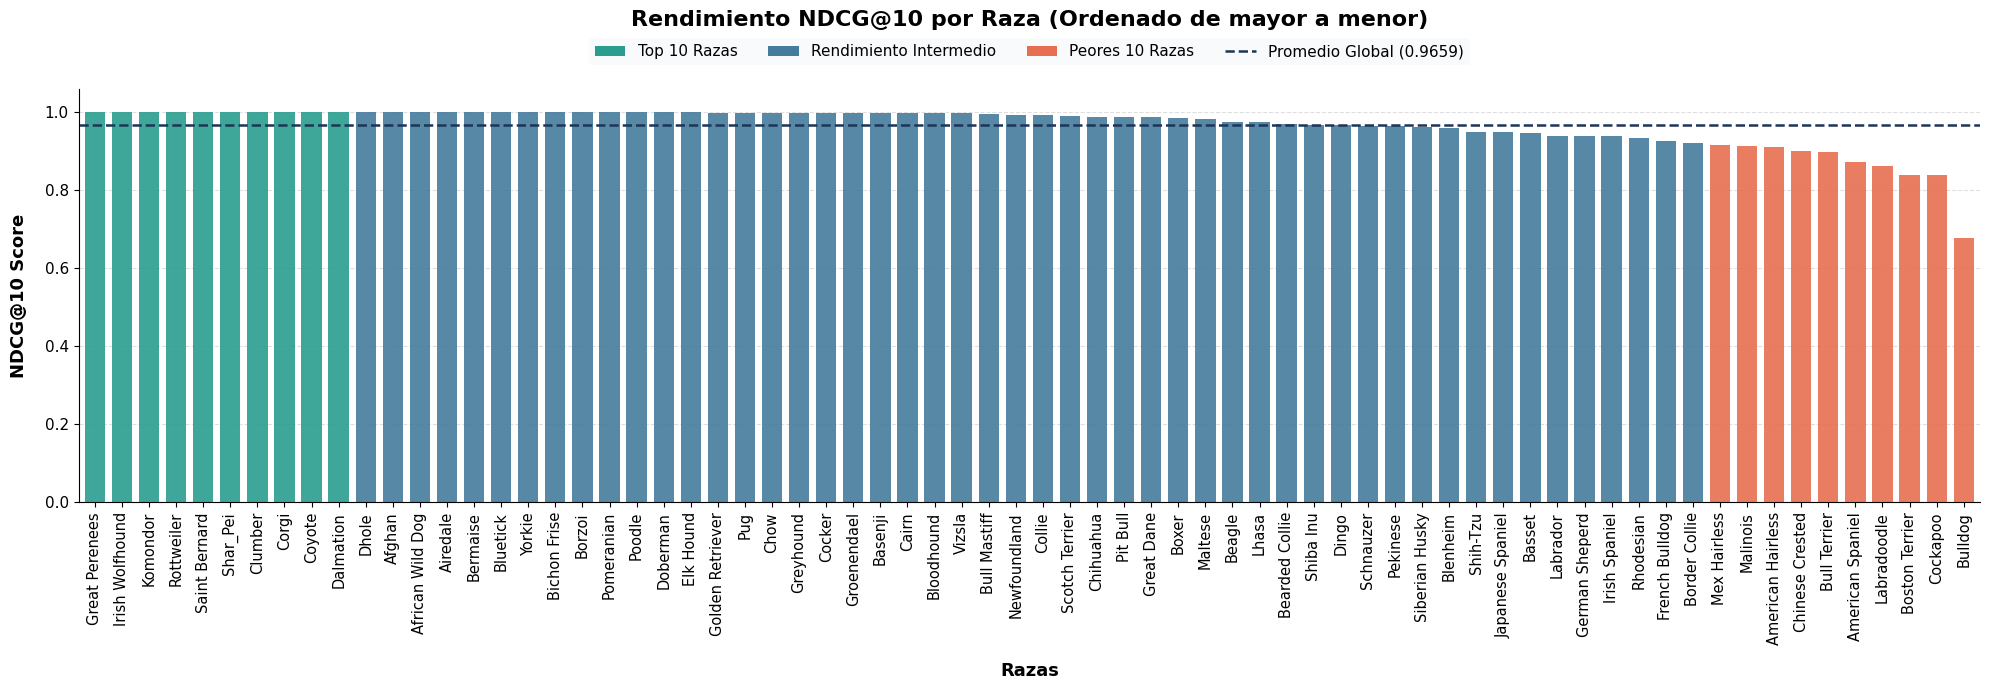

In [10]:
from matplotlib.patches import Patch
import matplotlib.lines as mlines

# Desempaquetar razas y scores ordenados (de la variable sorted_breeds)
breeds = [item[0] for item in sorted_breeds]
scores = [item[1] for item in sorted_breeds]
global_mean = np.mean(ndcg_scores)

# Crear figura un poco más alta y ancha para acomodar fuentes más grandes
fig, ax = plt.subplots(figsize=(20, 7), dpi=100)

# Asignar colores por categoría para fácil identificación
colors = ['#2a9d8f' if i < 10 else ('#e76f51' if i >= len(breeds) - 10 else '#457b9d') for i in range(len(breeds))]

# Dibujar barras
bars = ax.bar(range(len(breeds)), scores, color=colors, width=0.75, alpha=0.9, edgecolor='none')

# Línea horizontal con el promedio global
ax.axhline(y=global_mean, color='#1d3557', linestyle='--', linewidth=1.8)

# Configuración de límites y ejes para que la línea inferior no sobrecargue los costados
ax.set_xlim(-0.6, len(breeds) - 0.4)
ax.set_ylim(0, 1.06)

# Configuración de etiquetas con fuentes más grandes
ax.set_xticks(range(len(breeds)))
ax.set_xticklabels(breeds, rotation=90, fontsize=10.5, fontweight='medium')
ax.tick_params(axis='y', labelsize=11)

ax.set_ylabel("NDCG@10 Score", fontsize=13, fontweight='bold', labelpad=12)
ax.set_xlabel("Razas", fontsize=13, fontweight='bold', labelpad=12)

# Título con mayor separación vertical (pad=45) para hacer lugar a la leyenda arriba
ax.set_title("Rendimiento NDCG@10 por Raza (Ordenado de mayor a menor)", fontsize=16, fontweight='bold', pad=45)

# Estilo limpio
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Leyenda ubicada arriba en formato horizontal para no tapar ninguna barra
legend_elements = [
    Patch(facecolor='#2a9d8f', label='Top 10 Razas'),
    Patch(facecolor='#457b9d', label='Rendimiento Intermedio'),
    Patch(facecolor='#e76f51', label='Peores 10 Razas'),
    mlines.Line2D([], [], color='#1d3557', linestyle='--', linewidth=1.8, label=f'Promedio Global ({global_mean:.4f})')
]
ax.legend(
    handles=legend_elements, 
    bbox_to_anchor=(0.5, 1.14), 
    loc='upper center', 
    ncol=4, 
    frameon=True, 
    facecolor='#f8f9fa', 
    edgecolor='none', 
    fontsize=11
)

plt.tight_layout()
plt.show()

El **NDCG@10 promedio** da un resultado excelente, mayor a **0.95**. Esto significa que la búsqueda logra casi en todos los casos no solo encontrar la clase correcta dentro de los 10 resultados obtenidos, si no que también los posiciona lo más arriba posible en el ranking. La única raza que obtuvo de manera individual un puntaje menor a 0.8 es el *Bulldog*. A continuación se realiza un análisis para descubrir la razón de dicho resultado. 

# Análisis de clase Bulldog

El objetivo de este análisis es entender visualmente por qué el modelo pre-entrenado tiene un rendimiento menor para la clase **Bulldog**. Para lograrlo, el código evalúa todas las imágenes de prueba de esta raza y filtra aquellas con los peores puntajes NDCG (los casos donde el modelo falló más). Por cada una de estas consultas fallidas, se grafica la imagen original junto con los 5 perros que el algoritmo consideró más similares. Esto nos permite hacer una auditoría cualitativa rápida y descubrir con qué razas específicas (ej. Pugs o Boston Terriers) se está confundiendo nuestro modelo o si se está sesgando por el fondo de la foto.

 Analizando los errores de la raza: Bulldog...


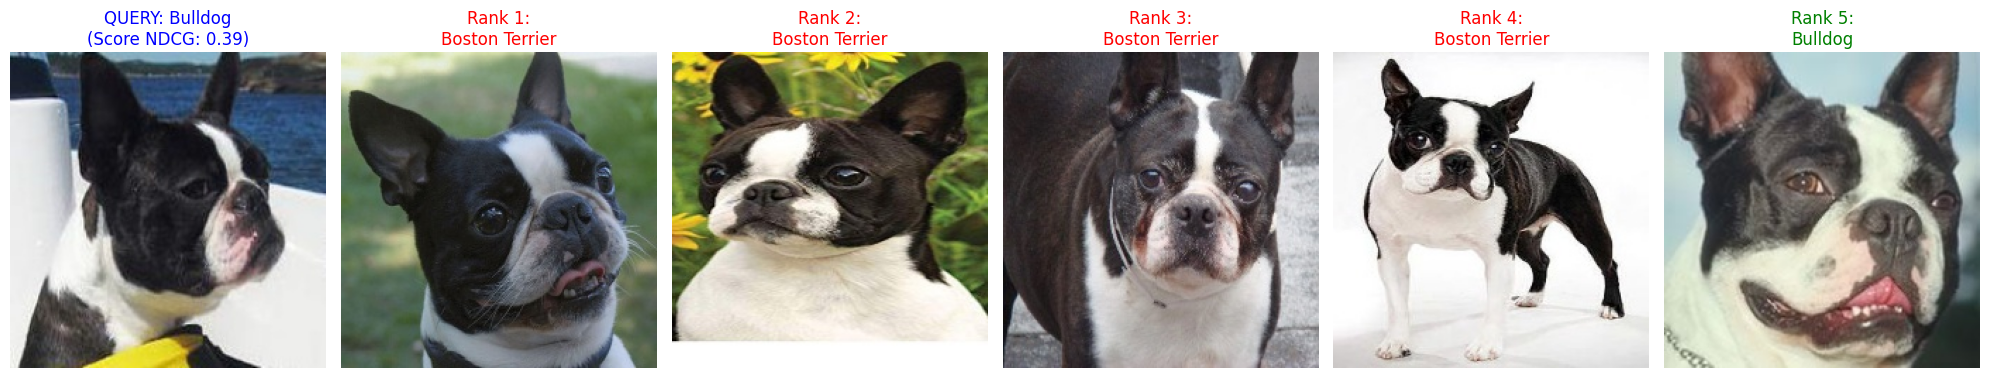

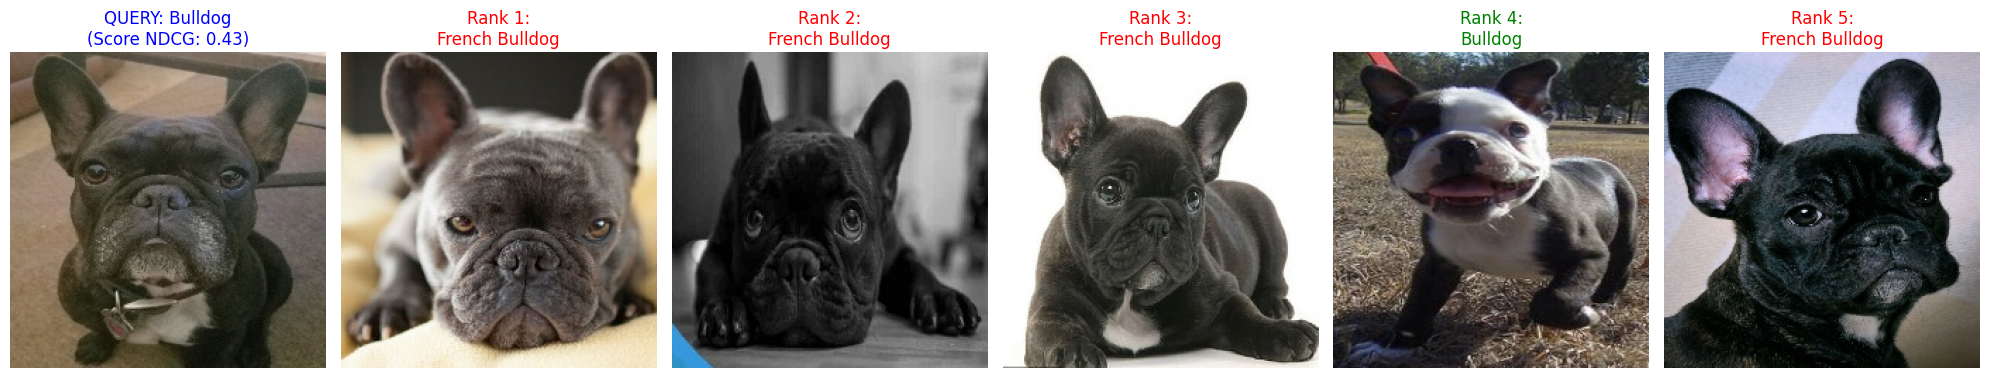

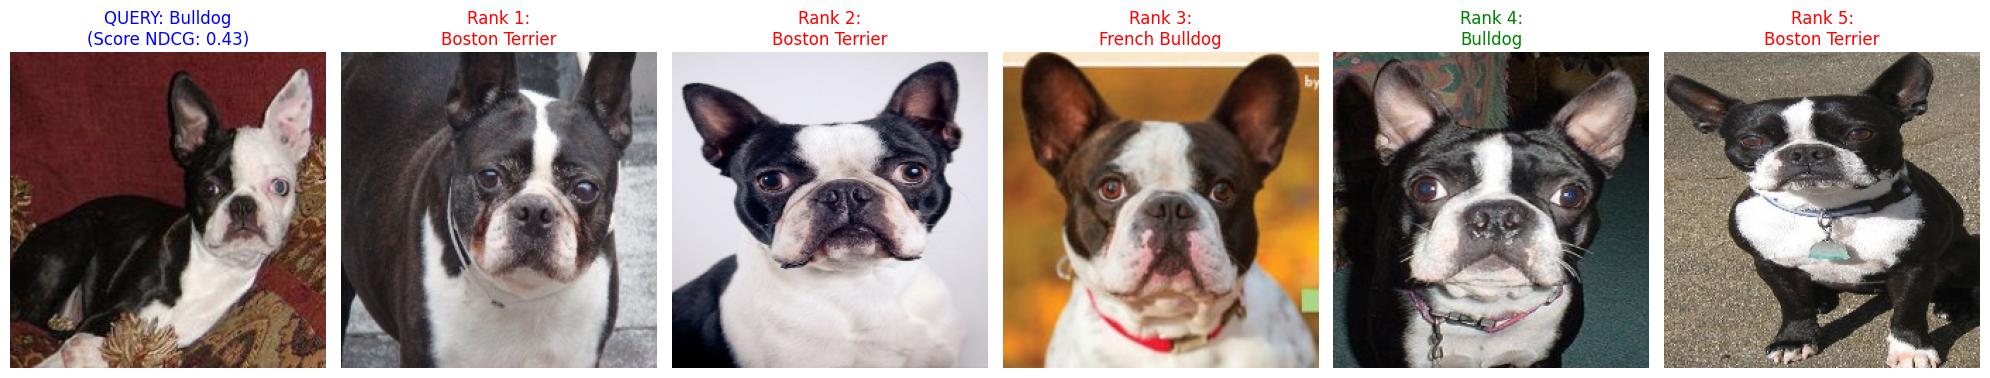

In [8]:
# Configuración del estudio
breed_to_study = "Bulldog"  # Nombre exacto de la carpeta
test_dir = Path("data/dataset/test") / breed_to_study

# Lista para guardar los peores resultados: (score, img_path, neighbors)
study_results = []

print(f" Analizando los errores de la raza: {breed_to_study}...")

if test_dir.exists():
    for img_path in test_dir.iterdir():
        if img_path.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"}:
            img = cv2.imread(str(img_path))
            if img is None: continue
                
            embedding = similarity.extract_embedding(img)
            neighbors = similarity.search_similar_images(embedding, top_k=5)
            
            relevances = [1.0 if n.breed == breed_to_study else 0.0 for n in neighbors]
            score = ndcg_at_k(relevances, k=5)
            
            # Guardamos los resultados si el score no fue perfecto
            if score < 1.0:
                study_results.append((score, img_path, neighbors))

# Ordenamos de PEOR a MEJOR score
study_results.sort(key=lambda x: x[0])

# Graficamos los 3 peores casos
top_worst = study_results[:3]

if not top_worst:
    print("¡No hubo errores! Todos los Bulldogs tuvieron score 1.0")
else:
    for score, img_path, neighbors in top_worst:
        fig, axes = plt.subplots(1, 6, figsize=(20, 4))
        
        # 1. Mostrar la imagen de Test (Query)
        query_img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        axes[0].imshow(query_img)
        axes[0].set_title(f"QUERY: {breed_to_study}\n(Score NDCG: {score:.2f})", color="blue")
        axes[0].axis("off")
        
        # 2. Mostrar los 5 resultados devueltos por la BD
        for i, n in enumerate(neighbors):
            # Leemos la imagen del vecino desde el disco usando su ruta
            n_img = cv2.cvtColor(cv2.imread(n.path), cv2.COLOR_BGR2RGB)
            
            # Si el vecino es Bulldog, título en verde. Si es un error, título en rojo.
            color = "green" if n.breed == breed_to_study else "red"
            
            axes[i+1].imshow(n_img)
            axes[i+1].set_title(f"Rank {i+1}:\n{n.breed}", color=color)
            axes[i+1].axis("off")
            
        plt.tight_layout()
        plt.show()


El resultado de este primer análisis parece demostrar que muchas imágenes de Boston Terriers fueron etiquetadas incorrectamente como Bulldogs y viceversa, lo que genera esa caída del rendimiento comparada con las demás clases. Para profundizar el análisis de este problema se realiza un estudio de clustering con KMeans para ver si las imágenes etiquetadas como Bulldog son claramente separables en clusters.

 Agrupando las imágenes de entrenamiento de Bulldog en 2 clústeres...

 CLÚSTER 0 (Contiene 46 imágenes)


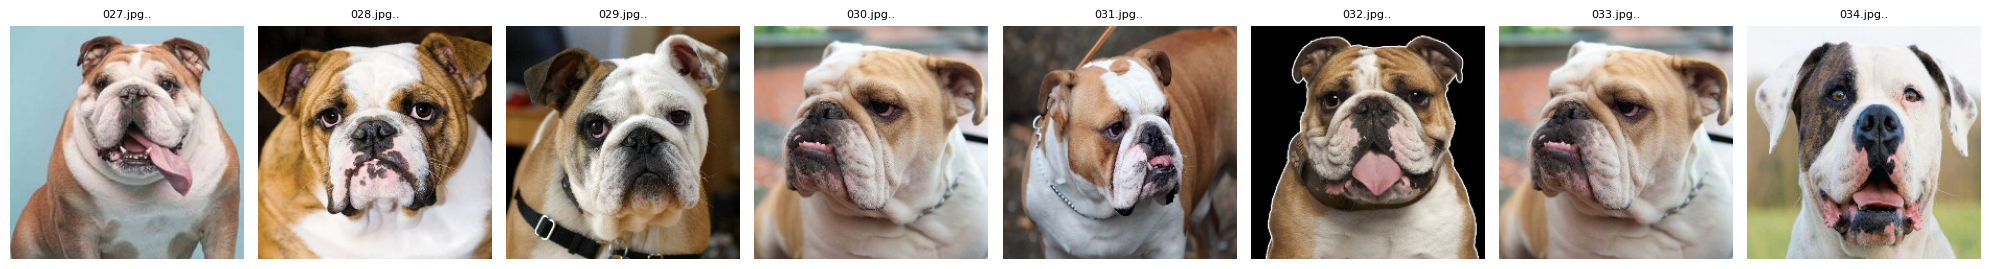


 CLÚSTER 1 (Contiene 79 imágenes)


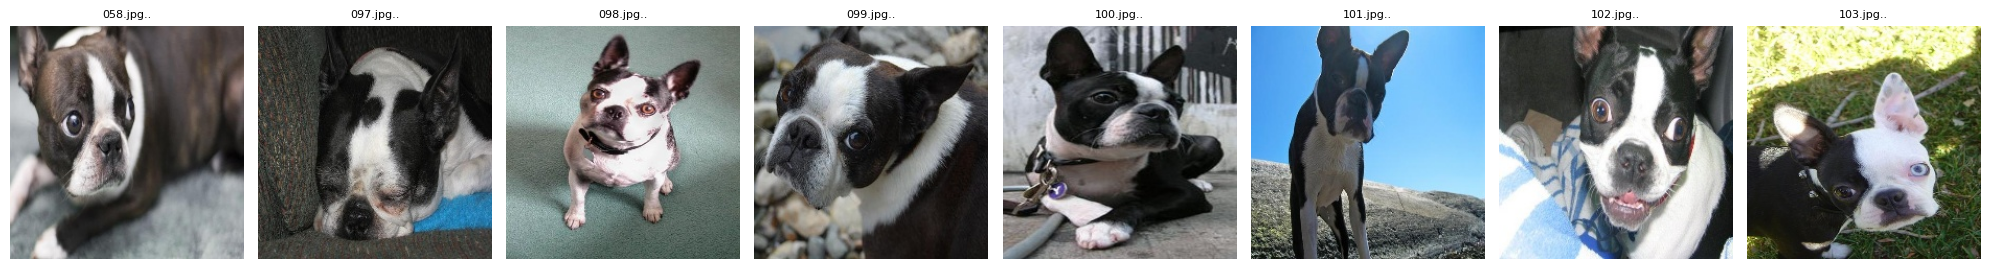

In [9]:
breed_to_study = "Bulldog"
train_dir = Path("data/dataset/train") / breed_to_study

print(f" Agrupando las imágenes de entrenamiento de {breed_to_study} en 2 clústeres...")

embeddings = []
image_paths = []

# 1. Extraemos los embeddings de todos los Bulldogs de entrenamiento
if train_dir.exists():
    for img_path in train_dir.iterdir():
        if img_path.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"}:
            img = cv2.imread(str(img_path))
            if img is not None:
                emb = similarity.extract_embedding(img)
                embeddings.append(emb)
                image_paths.append(img_path)

# 2. Aplicar K-Means con K=2
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(np.array(embeddings))

# 3. Visualizar los resultados
for cluster_id in range(2):
    # Encontramos las imágenes que cayeron en este clúster
    cluster_indices = np.where(labels == cluster_id)[0]
    
    print(f"\n===========================================")
    print(f" CLÚSTER {cluster_id} (Contiene {len(cluster_indices)} imágenes)")
    print(f"===========================================")
    
    # Mostramos las primeras 8 fotos de este clúster
    fig, axes = plt.subplots(1, min(8, len(cluster_indices)), figsize=(20, 3))
    if len(cluster_indices) == 1: axes = [axes] # Manejo de un solo subplot
    
    for ax, idx in zip(axes, cluster_indices[:8]):
        img_path = image_paths[idx]
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(img_path.name[:10] + "..", fontsize=8)
        
    plt.tight_layout()
    plt.show()


## Conclusión del Análisis de la Clase Bulldog

Tras realizar una auditoría visual de los peores resultados de la métrica NDCG@10 y aplicar técnicas de clustering no supervisado sobre los embeddings de ResNet34, se concluye que el bajo rendimiento de la clase **Bulldog** (score < 0.8) no se debe a una falla algorítmica del modelo de extracción de características, sino a un problema severo de **calidad de datos** en el dataset original.

Específicamente, se ha observado una contaminación cruzada significativa: una gran cantidad de imágenes etiquetadas como `Bulldog` pertenecen en realidad a la raza `Boston Terrier` (y potencialmente a mezclas similares como el French Bulldog). Como resultado:

1. El modelo de visión artificial reconoce correctamente los rasgos morfológicos de un Boston Terrier y recupera imágenes de esa misma raza de la base de datos con alta precisión.
2. Sin embargo, como el "Ground Truth" (la etiqueta oficial del dataset) declara erróneamente que la imagen de consulta es un Bulldog, el sistema clasifica las recuperaciones correctas de Boston Terriers como "falsos positivos".
3. Esto penaliza severamente el puntaje NDCG de la clase. Además, la presencia de Boston Terriers mal etiquetados dentro del propio conjunto de entrenamiento (Train Set) ensucia el espacio latente, provocando que búsquedas de verdaderos Bulldogs también devuelvan perros equivocados.
